# Computational Neuroscience Workshop

This notebook contains three short, hands-on modules:

 **Module 1** - Single LIF neuron (Brian2)\
 **Module 2** - 3-neuron microcircuit (Brian2)\
 **Module 3** - EEG playground (load pre-generated data 'simm_eeg.npy')

Required Python packages:\
Brian2, SciPy, NumPy and Matplotlib

## References

**Neuron models & computational neuroscience**

- Dayan, P., & Abbott, L. F. (2001). *Theoretical Neuroscience: Computational and Mathematical Modeling of Neural Systems*. MIT Press.
- Gerstner, W., & Kistler, W. M. (2002). *Spiking Neuron Models: Single Neurons, Populations, Plasticity*. Cambridge University Press. Available online: [neuronaldynamics.epfl.ch](https://neuronaldynamics.epfl.ch)
- Koch, C. (1999). *Biophysics of Computation: Information Processing in Single Neurons*. Oxford University Press.
- Hodgkin, A. L., & Huxley, A. F. (1952). A quantitative description of membrane current and its application to conduction and excitation in nerve. *Journal of Physiology*, 117(4), 500–544. [doi:10.1113/jphysiol.1952.sp004764](https://doi.org/10.1113/jphysiol.1952.sp004764)

**Wendling model & epilepsy**

- Wendling, F., Bartolomei, F., Bellanger, J. J., & Chauvel, P. (2002). Epileptic fast activity can be explained by a model of impaired GABAergic dendritic inhibition. *European Journal of Neuroscience*, 15(9), 1499–1508. [doi:10.1046/j.1460-9568.2002.01985.x](https://doi.org/10.1046/j.1460-9568.2002.01985.x)

**Software & tools**

- Stimberg, M., Brette, R., & Goodman, D. F. M. (2019). Brian 2, an intuitive and efficient neural simulator. *eLife*, 8, e47314. [doi:10.7554/eLife.47314](https://doi.org/10.7554/eLife.47314)
- Harris, C. R., et al. (2020). Array programming with NumPy. *Nature*, 585, 357–362. [doi:10.1038/s41586-020-2649-2](https://doi.org/10.1038/s41586-020-2649-2)
- Virtanen, P., et al. (2020). SciPy 1.0: fundamental algorithms for scientific computing in Python. *Nature Methods*, 17, 261–272. [doi:10.1038/s41592-020-0772-5](https://doi.org/10.1038/s41592-020-0772-5)
- Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science & Engineering*, 9(3), 90–95. [doi:10.1109/MCSE.2007.55](https://doi.org/10.1109/MCSE.2007.55)

## Module 1 - Single LIF neuron (Brian2)

Goal:\
To simulate a simple _leaky integrate-and-fire_ neuron using [_Brian2_](https://brian2.readthedocs.io/en/stable/#).\
Simulation runs for 500ms and will return the membrane potential and action potentials.

In [ ]:
# pip install brian2

In [ ]:
# ----------------------
# Imports (Module 1 & 2)
# ----------------------

import matplotlib.pyplot as plt
from brian2 import *
import brian2.numpy_ as np

In [ ]:
# ---------------------
# Module 1 - Parameters
# ---------------------

# Edit those lines to change neuron parameters:
I_ext = 0.5 * namp             # External current amplitude
tau_m = 20.0 * ms              # Membrane time constant
v_r = -65.0 * mV               # Resting potential
v_reset = -65.0 * mV           # Potentiel after spiking (= AP fired)
v_th = -50.0 * mV              # Threshold for spiking
refractory_period = 3.0 * ms   # Refractory period to allow spike decay
R = 100.0 * Mohm               # Membranar resistance
sigma = 2.0 * mV               # Noise intensity

# Define time-varying input current (pulses from 100-200 ms and 300-400 ms)
I_ext_values = np.zeros(500) * nA
I_ext_values[100:200] = I_ext
I_ext_values[300:400] = I_ext
I_ext_func = TimedArray(I_ext_values, dt=1*ms)

LIF equation:
$$\frac{dV}{dt} = \frac{-(V - V_{rest}) + R \times I_{ext}}{\tau_m} + \sigma \times \xi \times \sqrt{\tau_m}$$

<div style="display: flex; justify-content: center;">
    <table style="border-collapse: collapse; width: 60%; text-align: center;">
        <thead>
            <tr>
                <th style="border: 1px solid black; padding: 8px;">Symbol</th>
                <th style="border: 1px solid black; padding: 8px;">Meaning</th>
                <th style="border: 1px solid black; padding: 8px;">Typical value</th>
            </tr>
        </thead>
        <tbody>
            <tr>
                <td style="border: 1px solid black; padding: 8px;">V</td>
                <td style="border: 1px solid black; padding: 8px;">Membrane potential</td>
                <td style="border: 1px solid black; padding: 8px;">&minus;65 to &minus;50 mV</td>
            </tr>
            <tr>
                <td style="border: 1px solid black; padding: 8px;">V<sub>rest</sub></td>
                <td style="border: 1px solid black; padding: 8px;">Resting potential (leak target)</td>
                <td style="border: 1px solid black; padding: 8px;">&minus;65 mV</td>
            </tr>
            <tr>
                <td style="border: 1px solid black; padding: 8px;">τ<sub>m</sub></td>
                <td style="border: 1px solid black; padding: 8px;">Membrane time constant</td>
                <td style="border: 1px solid black; padding: 8px;">20 ms</td>
            </tr>
            <tr>
                <td style="border: 1px solid black; padding: 8px;">R</td>
                <td style="border: 1px solid black; padding: 8px;">Membrane resistance</td>
                <td style="border: 1px solid black; padding: 8px;">100 MΩ</td>
            </tr>
            <tr>
                <td style="border: 1px solid black; padding: 8px;">I<sub>ext</sub></td>
                <td style="border: 1px solid black; padding: 8px;">External current</td>
                <td style="border: 1px solid black; padding: 8px;">0 to 1 nA</td>
            </tr>
        </tbody>
    </table>
</div>

## Biological context

A real neuron constantly receives thousands of synaptic inputs - some excitatory, some inhibitory. 
These inputs cause small fluctuations in the **membrane potential** _V_, the electrical voltage across the cell membrane.

The **leaky integrate-and-fire (LIF)** model captures the two key behaviours of a neuron in the simplest possible way:
- **Integrate** - incoming current pushes _V_ toward a firing threshold. 
- **Leak** - the membrane passively returns to its resting potential when no input arrives (like a leaky capacitor)

When _V_ crosses the threshold V_th, the neuron fires an **action potential** and _V_ is immediatly reset. 
The refractory period then prevents firing again for a few milliseconds, mimicking the sodium channel inactivation after a real spike. 

This abstraction discards the detailed ion channel dynamics of the [Hodgkin-Huxley model](https://doi.org/10.1113/jphysiol.1952.sp004764) but reproduces the essential input-output behaviour of a spiking neuron - at a fraction of the computation cost. 

**Notes:**
- Try to change '```I_ext```' to adapt the strengh of the external current application;
- Change '```tau_m```' to see how membrane integers;
- Change '```v_th```' to ease action potential firing;

In [ ]:
# ----------------------------
# Module 1 - Equations & model
# ----------------------------
start_scope()  # Essentiel to avoid any conflit with Brian2

eqs = """
dv/dt = (-(v - v_r) + R * I_ext_func(t)) / tau_m + sigma * xi * tau_m ** -0.5: volt (unless refractory)
"""

# Creat a single neuron
G = NeuronGroup(1, eqs, threshold='v>v_th', reset='v = v_reset',
               refractory=refractory_period, method='euler')
G.v = v_r

# Monitors - Objects that keep track of what's happening
state_mon = StateMonitor(G, 'v', record=True)
spike_mon = SpikeMonitor(G, variables='v')

# Run simulation for 500ms
dur = 500
print(f"Ongoing simulation for {dur}ms...\n")
run(dur*ms)
print("Simulation done!")

Ongoing simulation for 500ms...

Simulation done!


Before plotting the results:
* How many spikes do you expect during each 100ms stimulus windowns? 
* What happens if you double '```I_ext```'? 
* Write your prediction below, then plot!

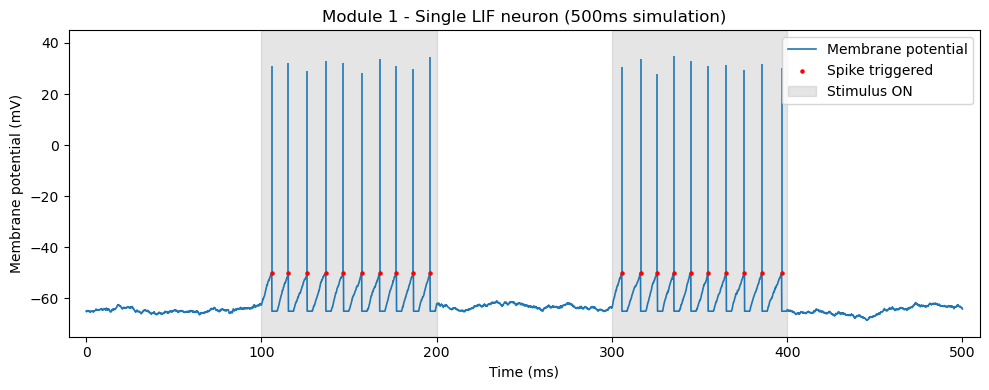

In [ ]:
# -------------------
# Module 1 - Plotting
# -------------------

fig, ax = plt.subplots(figsize=(10, 4))

# 1. Plot the membrane potential
ax.plot(state_mon.t/ms, state_mon.v[0]/mV, lw=1.2, color='tab:blue', label='Membrane potential')

# 2. Draw the vertical action potentials
    # Just for visual purposes, we draw a line from the threshold up to +30mV-ish for every recorded spike
num_spikes = len(spike_mon.t)
random_peaks = np.random.normal(loc=30.0, scale=3.0, size=num_spikes)  # Randomize spike heights around 30mV
ax.vlines(spike_mon.t/ms, ymin=v_th/mV, ymax=random_peaks, color='tab:blue', lw=1.2)

# Optional: keep red dots to mark the threshold crossing clearly
ax.scatter(spike_mon.t/ms, np.ones(len(spike_mon.t))*(v_th/mV),
            color='red', s=5, zorder=5, label='Spike triggered')

# Optional: add a shaded background to show when the stimulus is active
ax.axvspan(100, 200, color='grey', alpha=0.2, label='Stimulus ON')
ax.axvspan(300, 400, color='grey', alpha=0.2)

ax.set_xlabel('Time (ms)')
ax.set_ylabel('Membrane potential (mV)')
ax.set_title('Module 1 - Single LIF neuron (500ms simulation)')
ax.set_ylim(v_r/mV - 10, max(random_peaks) + 10)  # Set y-limits to show resting potential and spikes clearly
ax.set_xlim(-10, 510)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

## Module 2 - 3-neuron microcircuit (Brian2)

Goal:\
Reccurent minimal microcircuit with 2 excitatory (E) LIF neurons and 1 inhibitor (I).\
You can change one or two synaptic weights.
Connection : 
- E → E (recurrent)
- E → I
- I → E (inhibitory feedback)

We'll create a raster plot and a population estimate.

In [ ]:
# -----------------------------
# Module 2 - Network of neurons
# -----------------------------

start_scope()

# Simulation parameters
sim_dur = 1_000.0 * ms  # runs for one second

# Shared neuron parameters
tau_m = 20.0 * ms
v_rest = -65.0 * mV
v_reset = -65.0 * mV
v_tresh = -50.0 * mV
refractory_period = 5.0 * ms
R = 100.0 * Mohm
sigma = 2.5 * mV

# External current parameters - Change them and see what's happening!
I_e = 0.22 * nA  # External current for excitatory neurons
I_i = 0.18 * nA  # External current for inhibitory neurons

In [ ]:
# ----------------------------
# Module 2 - Equations & model
# ----------------------------

# Creation of neuron groups: 2 Excitatory and 1 Inhibitory
eqs = '''
dv/dt = (-(v - v_rest) + R*I_inj) / tau_m + sigma * xi * tau_m ** -0.5: volt (unless refractory)
I_inj : amp
'''

E = NeuronGroup(2, eqs, threshold='v>v_tresh', reset='v=v_rest',
                refractory=refractory_period, method='euler')
I = NeuronGroup(1, eqs, threshold='v>v_tresh', reset='v=v_rest',
                refractory=refractory_period, method='euler')

# Initialisation of membrane potentials with slight random heterogeneity to avoid perfect synchrony
E.v = v_rest + (np.random.rand(len(E)) - 0.5) * 5.0 * mV  # Add random noise to initial potentials
I.v = v_rest + (np.random.rand(len(I)) - 0.5) * 5.0 * mV  # Add random noise to initial potentials

# Define injected currents for each group
E.I_inj = I_e
I.I_inj = I_i 

In [ ]:
# --------------------------------
# Module 2 - Synapses & simulation
# --------------------------------

# Synaptic weights (to modify) - Change those values and see how the network dynamics change!
w_EE = 1.5 * mV   # weights E --> E 
w_EI = 2.0 * mV   # weights E --> I 
w_IE = -3.0 * mV  # weights I --> E (negative for inhibition)

# Synapses creation 
    # E --> E (recurrent, connected to avoid autapse)
S_EE = Synapses(E, E, on_pre='v_post += w_EE')
S_EE.connect(condition='i!=j')  # No autapse

    # E --> I 
S_EI = Synapses(E, I, on_pre='v_post += w_EI')
S_EI.connect()

    # I --> E (inhibition)
S_IE = Synapses(I, E, on_pre='v_post += w_IE')
S_IE.connect()

# Monitors
    # Spike monitors to record spike times
spike_mon_E = SpikeMonitor(E)
spike_mon_I = SpikeMonitor(I)

    # Population rate monitor to record firing rates and state monitor to record membrane potentials
state_mon_E = StateMonitor(E, 'v', record=True)
state_mon_I = StateMonitor(I, 'v', record=True)

    # Excitatory population rate monitor
rate_mon_E = PopulationRateMonitor(E)
rate_mon_I = PopulationRateMonitor(I)

# Launch the simulation
print(f"Ongoing simulation for {sim_dur}ms...\n")
run(sim_dur)
print("Simulation done!")

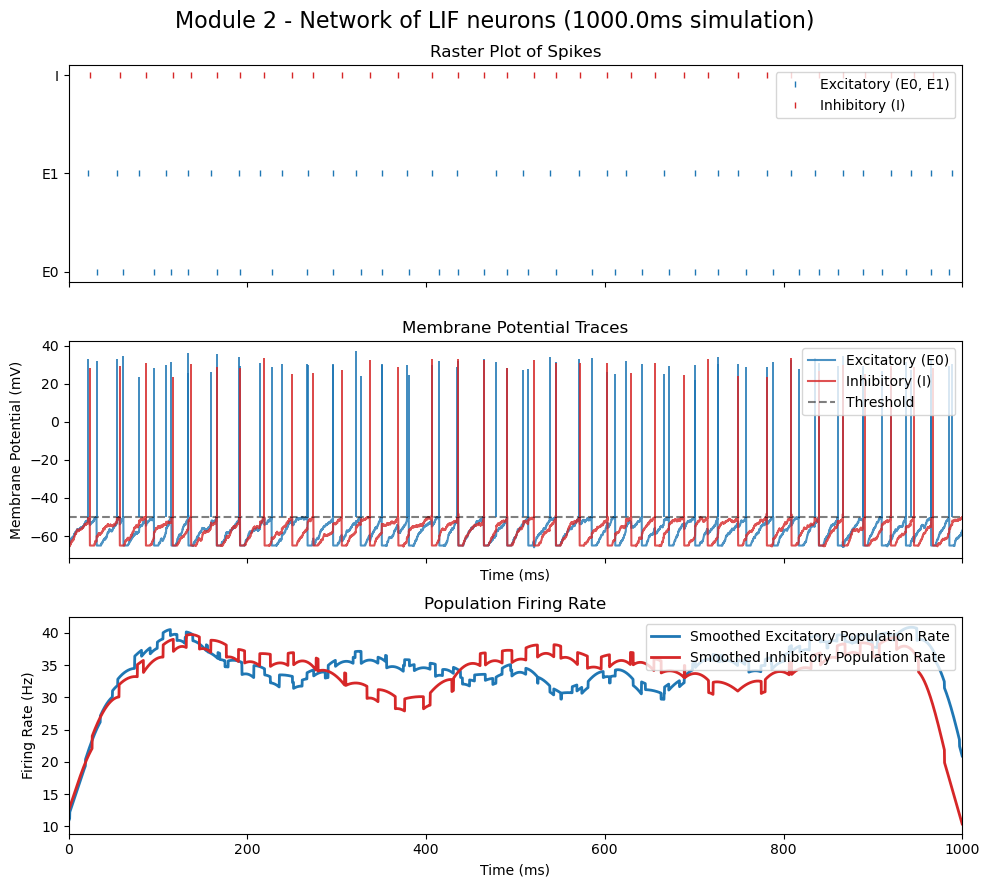

In [ ]:
# ----------------
# Module 2 - Plots
# ----------------

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

# Top plot: Raster plot of spikes
ax1.plot(spike_mon_E.t/ms, spike_mon_E.i, '|', markersize=5, color='tab:blue', label='Excitatory (E0, E1)')
ax1.plot(spike_mon_I.t/ms, spike_mon_I.i + 2, '|', markersize=5, color='tab:red', label='Inhibitory (I)')  # Offset I index for visualization
ax1.set_yticks([0, 1, 2])  # Set y-ticks to show neuron indices clearly
ax1.set_yticklabels(['E0', 'E1', 'I'])
ax1.set_title('Raster Plot of Spikes')
ax1.legend(loc='upper right')

# Middle plot: Membrane potential traces (The "why" behind the raster plot)
ax2.plot(state_mon_E.t/ms, state_mon_E.v[0]/mV, color='tab:blue', label='Excitatory (E0)', alpha=0.8)
ax2.plot(state_mon_I.t/ms, state_mon_I.v[0]/mV, color='tab:red', label='Inhibitory (I)', alpha=0.8)  # Offset I index for visualization
ax2.axhline(v_tresh/mV, color='k', linestyle='--', alpha=0.5, label='Threshold')  # Add threshold line for reference

    # Just for visual purposes, we draw a line from the threshold up to +30mV-ish for every recorded spike
num_spikes_e = len(spike_mon_E.t)
num_spikes_i = len(spike_mon_I.t)
random_peaks_e = np.random.normal(loc=30.0, scale=3.0, size=num_spikes_e)  # Randomize spike heights around 30mV
random_peaks_i = np.random.normal(loc=30.0, scale=3.0, size=num_spikes_i)  # Randomize spike heights around 30mV
ax2.vlines(spike_mon_E.t/ms, ymin=v_tresh/mV, ymax=random_peaks_e, color='tab:blue', lw=1.2)
ax2.vlines(spike_mon_I.t/ms, ymin=v_tresh/mV, ymax=random_peaks_i, color='tab:red', lw=1.2)

ax2.set_xlabel('Time (ms)')
ax2.set_ylabel('Membrane Potential (mV)')
ax2.set_title('Membrane Potential Traces')
ax2.legend(loc='upper right')
ax2.set_xlim(0, float(sim_dur/ms))

# Bottom plot: Population firing rate of excitatory neurons
    # We use a smoothed version of the population rate for better visualization
window_width = 30 * ms
smoothed_rate_e = rate_mon_E.smooth_rate(window='gaussian', width=window_width) / Hz
smoothed_rate_i = rate_mon_I.smooth_rate(window='gaussian', width=window_width) / Hz

ax3.plot(rate_mon_E.t/ms, smoothed_rate_e, color='tab:blue', lw=2, label='Smoothed Excitatory Population Rate')
ax3.plot(rate_mon_I.t/ms, smoothed_rate_i, color='tab:red', lw=2, label='Smoothed Inhibitory Population Rate')
ax3.set_xlabel('Time (ms)')
ax3.set_ylabel('Firing Rate (Hz)')
ax3.set_title('Population Firing Rate')
ax3.legend(loc='upper right')
ax3.set_xlim(0, float(sim_dur/ms))

fig.suptitle(f'Module 2 - Network of LIF neurons ({sim_dur/ms}ms simulation)', fontsize=16)

plt.tight_layout()
plt.show()

Now, go back to the synaptic weight definition and try these changes:
* Set '```w_IE = 0```' - remove inhibition entirely. What do you predict? 
* Set '```w_IE = +3.0```' (positive). What happens to E neurons? 
* Double '```w_EE```' to '```3.0 mV```'. Does the network synchornise or desynchronise?

Run each, observe the raster plot, then discuss.

## Module 3 - Low-level analysis on EEG-like data

Goal:\
Construct a spectrogram of SEEG from epileptic like data.

Data has been generated according to the [Wendling et al.](https://onlinelibrary.wiley.com/doi/10.1046/j.1460-9568.2002.01985.x) model from a home made standalone (https://github.com/Jerem-loq/SEEG-Wendling/blob/main/generate_wendling2.py).

In [ ]:
# ------------------
# Imports (Module 3)
# ------------------

import numpy as np
from scipy.signal import spectrogram

In [ ]:
# --------------------------------------
# Module 3 - Loading and extracting data
# --------------------------------------

data = np.load("simm_eeg_trace_NL_test_6.npy")
data_parameters = np.load("sim_eeg_param_NL_test_6.npz")

time = data_parameters["time"].flatten()
exc = data_parameters["A"]
slow_inh = data_parameters["B"]
fast_inh = data_parameters["G"]

In [ ]:
# --------------------------------
# Module 3 - Parameters definition 
# --------------------------------

fs = 1_000                                       # sampling rate (Hz) | frequency at which data is saved
duration = 250.0                                 # seconds
n_samples = int(duration * fs)
t = np.linspace(0, duration, n_samples)

# Some print statements to check the loaded data and its structure
print(f"Signal shape: \t{int(data.shape[0])} points")
print(f"Time shape: \t{int(time.shape[0])} points")
print(f"Duration: \t{time[-1]:.1f} seconds")
print(f"Sampling rate: \t{fs} Hz")
print(f"Excitation parameter: \t\t{exc.min():.2f} to {exc.max():.2f}")
print(f"Slow inhibitory parameter: \t{slow_inh.min():.2f} to {slow_inh.max():.2f}")
print(f"Fast inhibitory parameter: \t{fast_inh.min():.2f} to {fast_inh.max():.2f}")

Signal shape: 	250000 points
Time shape: 	250000 points
Duration: 	250.0 seconds
Sampling rate: 	1000 Hz
Excitation parameter: 		5.00 to 5.00
Slow inhibitory parameter: 	5.00 to 40.00
Fast inhibitory parameter: 	5.00 to 20.00


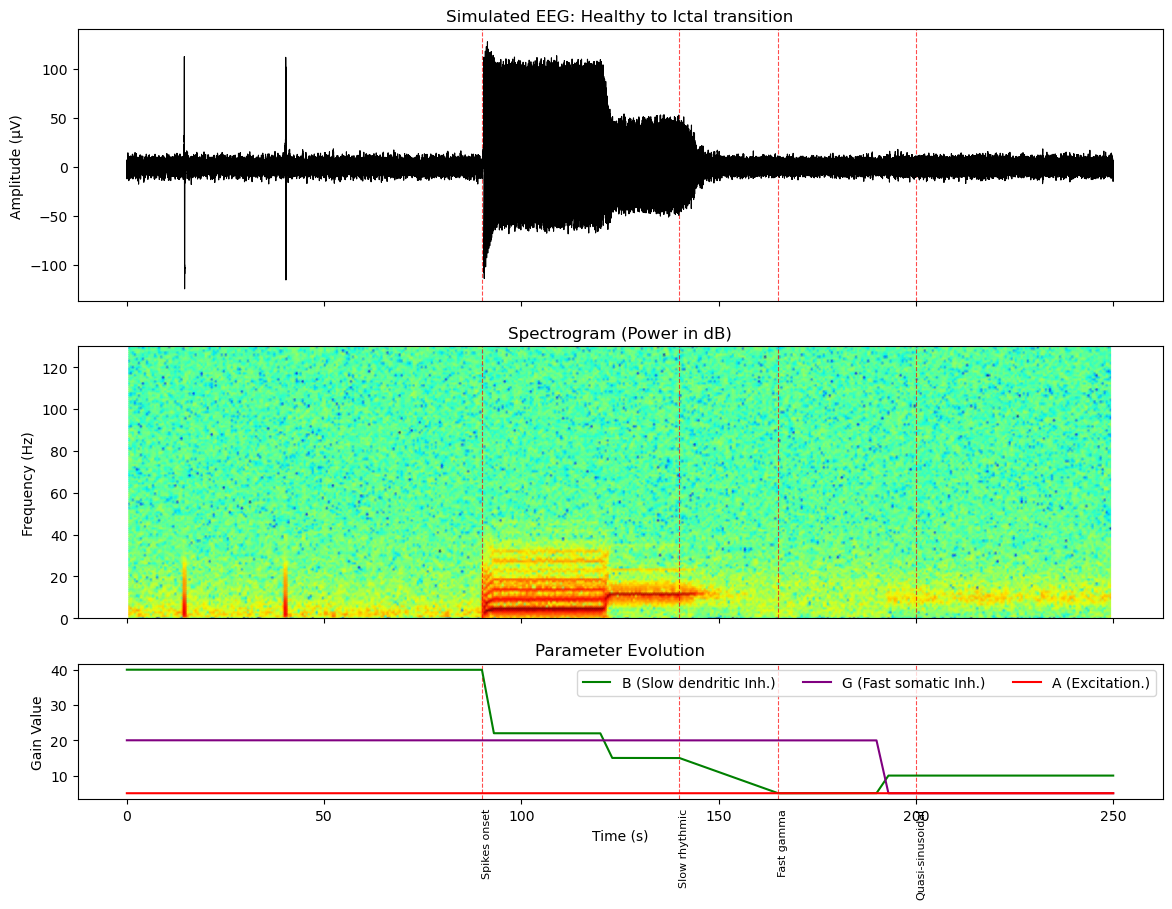

In [ ]:
# --------------------
# Module 3 - Plot data
# --------------------

transitions = {90: "Spikes onset", 140: "Slow rhythmic", 165: "Fast gamma", 200: "Quasi-sinusoidal"}

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10), sharex=True,
                                gridspec_kw={'height_ratios': [2, 2, 1]})

for t_vent, label in transitions.items():
    for ax in [ax1, ax2, ax3]:
        ax.axvline(t_vent, color='red', lw=0.8, linestyle='--', alpha=0.7)
    ax.text(t_vent, ax.get_ylim()[1] * 0.85, label, fontsize=8, color='black',
            rotation=90, verticalalignment='top')

# 1. Raw trace
ax1.plot(time, data, color='black', linewidth=0.8)
ax1.set_title("Simulated EEG: Healthy to Ictal transition")
ax1.set_ylabel("Amplitude (µV)")

# 2. Spectrogram
f_spec, t_spec, Sxx = spectrogram(data, fs, nperseg=1024, noverlap=512)
freq_mask = f_spec <= 130  # Limit to 130 Hz to see gamma clearly
im = ax2.pcolormesh(t_spec + time[0], f_spec[freq_mask],
                    10 * np.log10(Sxx[freq_mask, :]),
                    shading='gouraud', cmap='jet')
ax2.set_ylabel("Frequency (Hz)")
ax2.set_title("Spectrogram (Power in dB)")
# fig.colorbar(im, ax=ax2, label='Power(dB)')

# 3. Parameters
ax3.plot(time, slow_inh, label="B (Slow dendritic Inh.)", color='green')
ax3.plot(time, fast_inh, label="G (Fast somatic Inh.)", color='purple')
ax3.plot(time, exc, label="A (Excitation.)", color='red')
ax3.set_title("Parameter Evolution")
ax3.set_ylabel("Gain Value")
ax3.set_xlabel("Time (s)")
ax3.legend(loc='upper right', ncol=3)